# EDA: word and character distributions for text recognition

The recognizer (ViT → BERT, `training/train_trocr.py`) is trained on word crops cut from the ground-truth boxes, and it
predicts **one character at a time**. Two questions:

1. How imbalanced are the words and characters it learns from?
2. Could that explain its failure mode? On ground-truth crops the current checkpoint reads most words as `1`, `Toll` or
   `2,000` (character error rate 0.71).

Run from the repo root (or from `notebooks/`) with `dataset_receipt/` in place. The split is the same one training
uses (`split_receipts`, seed 42).

In [1]:
import collections, os, re, warnings
warnings.filterwarnings("ignore", message="IProgress not found")  # tqdm, via transformers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if not os.path.isdir("dataset_receipt") and os.path.isdir("../dataset_receipt"):
    os.chdir("..")
from ocr.dataset import split_receipts

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREY = "#2563EB", "#F59E0B", "#9CA3AF"

md = pd.read_pickle("dataset_receipt/metadata.pkl")
train, val, test = split_receipts(md, seed=42)
words = [w for ws in md.words for w in ws]
train_words = [w for ws in train.words for w in ws]
test_words = [w for ws in test.words for w in ws]
print(f"{len(md)} receipts, {len(words):,} words, {len(set(words)):,} distinct")
print(f"split (receipts): train {len(train)}, val {len(val)}, test {len(test)}")
print(f"split (words):    train {len(train_words):,}, val {sum(map(len, val.words)):,}, test {len(test_words):,}")

200 receipts, 4,542 words, 1,695 distinct
split (receipts): train 140, val 30, test 30
split (words):    train 3,206, val 707, test 629


## 1. Word frequencies: a few words dominate, most appear once

'1' alone: 8.1% of all words
top  1 words cover 8.1%
top  5 words cover 16.3%
top 10 words cover 21.0%
top 50 words cover 35.0%
words seen once: 1,078 = 64% of the vocabulary, 23.7% of all words


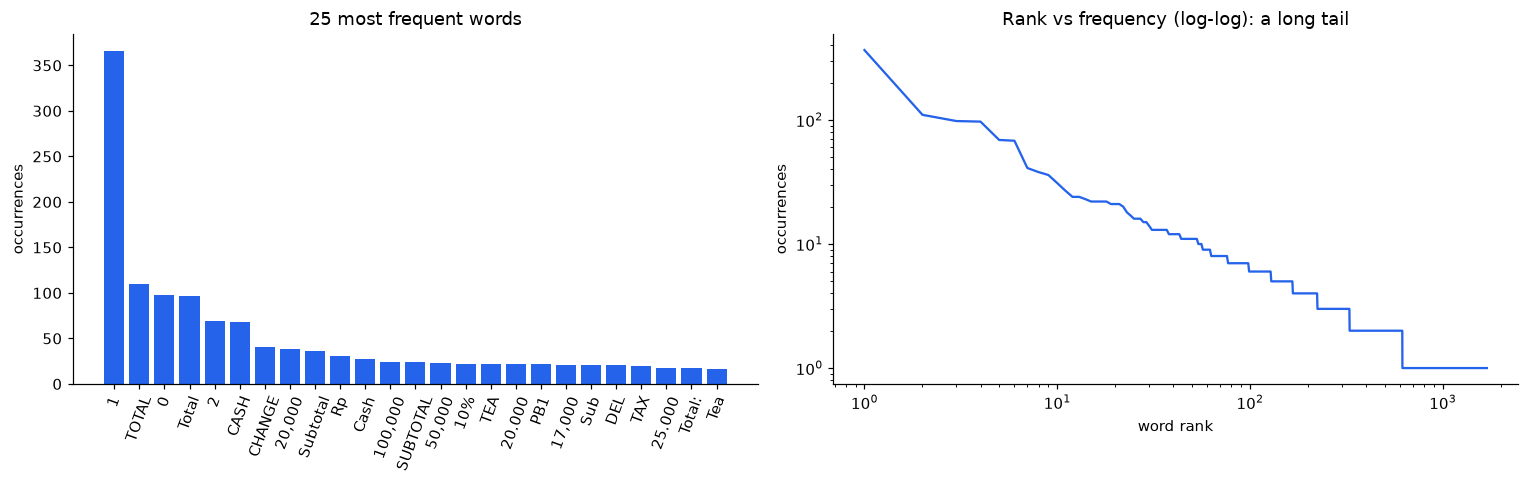

In [2]:
counts = collections.Counter(words)
top = counts.most_common(25)
total = len(words)
print(f"'1' alone: {counts['1'] / total:.1%} of all words")
for k in (1, 5, 10, 50):
    print(f"top {k:>2} words cover {sum(n for _, n in counts.most_common(k)) / total:.1%}")
singletons = [w for w, n in counts.items() if n == 1]
print(f"words seen once: {len(singletons):,} = {len(singletons) / len(counts):.0%} of the vocabulary, "
      f"{len(singletons) / total:.1%} of all words")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))
ax1.bar([w for w, _ in top], [n for _, n in top], color=BLUE)
ax1.set_title("25 most frequent words"); ax1.set_ylabel("occurrences")
ax1.tick_params(axis="x", rotation=70)
freqs = np.array(sorted(counts.values(), reverse=True))
ax2.loglog(np.arange(1, len(freqs) + 1), freqs, color=BLUE)
ax2.set_title("Rank vs frequency (log-log): a long tail"); ax2.set_xlabel("word rank"); ax2.set_ylabel("occurrences")
plt.tight_layout(); plt.show()

## 2. What kind of tokens: numbers are ~40% of all words

word                            47.8%
number                          41.0%
other (e.g. 10%, S-Ovaltine)     6.7%
letters + digits                 3.5%
punctuation                      1.0%


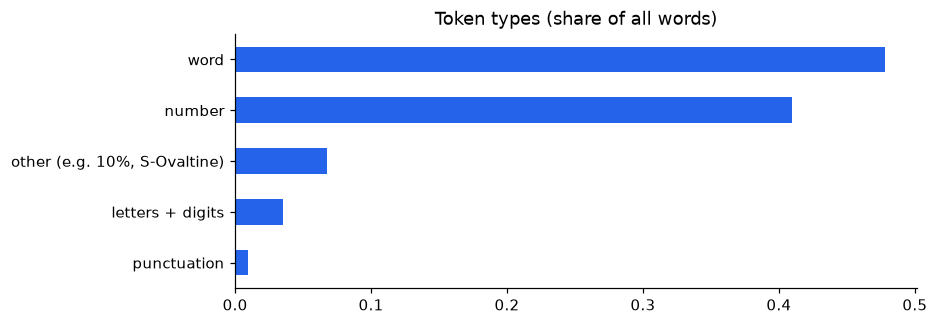

In [3]:
AMOUNT = re.compile(r"^[-(]?(rp\.?\s*)?@?\d{1,3}([.,]\d{3})+([.,]\d{2})?\)?$|^\d+$", re.I)

def kind(w):
    if AMOUNT.match(w.strip(":")):
        return "number"
    if re.fullmatch(r"[A-Za-z]+[.:]?", w):
        return "word"
    if any(c.isdigit() for c in w) and any(c.isalpha() for c in w):
        return "letters + digits"
    if not any(c.isalnum() for c in w):
        return "punctuation"
    return "other (e.g. 10%, S-Ovaltine)"

kinds = pd.Series([kind(w) for w in words]).value_counts(normalize=True)
print(kinds.map("{:.1%}".format).to_string())
kinds.plot.barh(color=BLUE, figsize=(8, 3), title="Token types (share of all words)").invert_yaxis()
plt.show()

## 3. Characters, which is what the model actually predicts

The tokenizer has one token per character, so the decoder's training signal is the character distribution.

21,693 characters, 84 distinct
'0' alone: 17.2% of all characters
{'digit': '35.5%', 'upper': '34.2%', 'lower': '21.4%', 'punct / space / other': '9.0%'}
12 characters seen fewer than 10 times: '$'×1 '<'×1 '>'×1 '_'×1 '~'×1 "'"×4 'q'×5 'z'×5 ']'×6 '['×7 'Z'×8 '&'×9


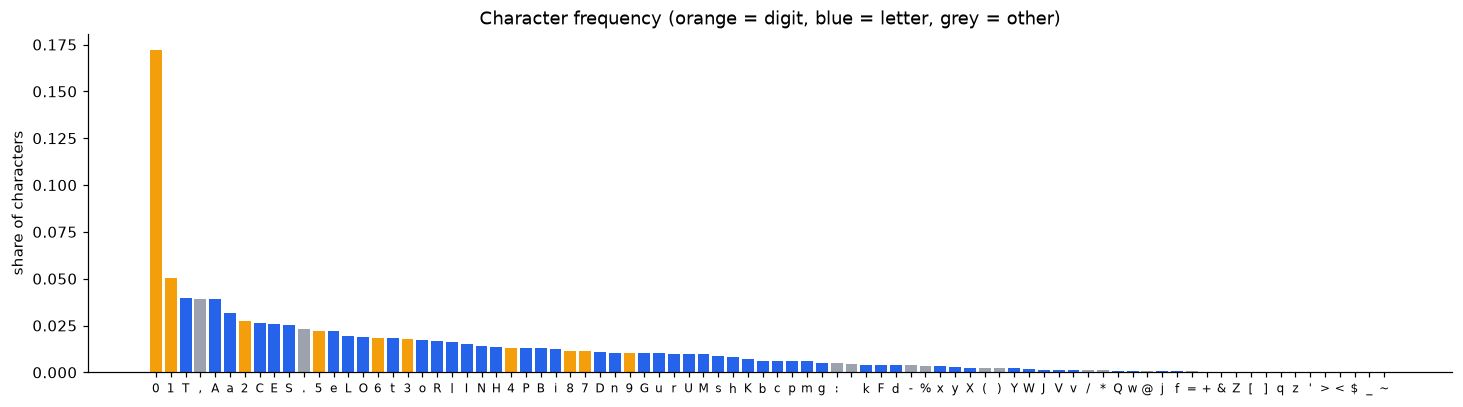

In [4]:
chars = collections.Counter(c for w in words for c in w)
n_chars = sum(chars.values())
by_class = {"digit": sum(n for c, n in chars.items() if c.isdigit()),
            "upper": sum(n for c, n in chars.items() if c.isupper()),
            "lower": sum(n for c, n in chars.items() if c.islower())}
by_class["punct / space / other"] = n_chars - sum(by_class.values())
print(f"{n_chars:,} characters, {len(chars)} distinct")
print(f"'0' alone: {chars['0'] / n_chars:.1%} of all characters")
print({k: f"{v / n_chars:.1%}" for k, v in by_class.items()})
rare = sorted((n, c) for c, n in chars.items() if n < 10)
print(f"{len(rare)} characters seen fewer than 10 times:", " ".join(f"{c!r}×{n}" for n, c in rare))

ordered = chars.most_common()
colors = [ORANGE if c.isdigit() else BLUE if c.isalpha() else GREY for c, _ in ordered]
plt.figure(figsize=(16, 4))
plt.bar(range(len(ordered)), [n / n_chars for _, n in ordered], color=colors)
plt.xticks(range(len(ordered)), [c for c, _ in ordered], fontsize=8)
plt.title("Character frequency (orange = digit, blue = letter, grey = other)"); plt.ylabel("share of characters")
plt.show()

## 4. Word length: short words, many single characters

mean     4.8
50%      5.0
max     32.0
single-character words: 14.3% (mostly quantities like '1')
words longer than the decoder's 40-token limit: 0


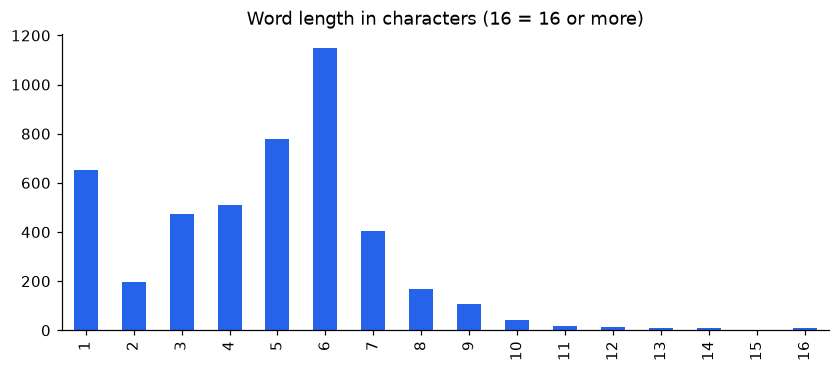

In [5]:
lengths = pd.Series([len(w) for w in words])
print(lengths.describe()[["mean", "50%", "max"]].round(1).to_string())
print(f"single-character words: {(lengths == 1).mean():.1%} (mostly quantities like '1')")
print(f"words longer than the decoder's 40-token limit: {(lengths >= 40).sum()}")
lengths.clip(upper=16).value_counts().sort_index().plot.bar(color=BLUE, figsize=(9, 3.5),
    title="Word length in characters (16 = 16 or more)")
plt.show()

## 5. Train vs test: can the model memorize, or must it read?

test words never seen in training: 34.3%
test characters never seen in training: ['_', 'z']


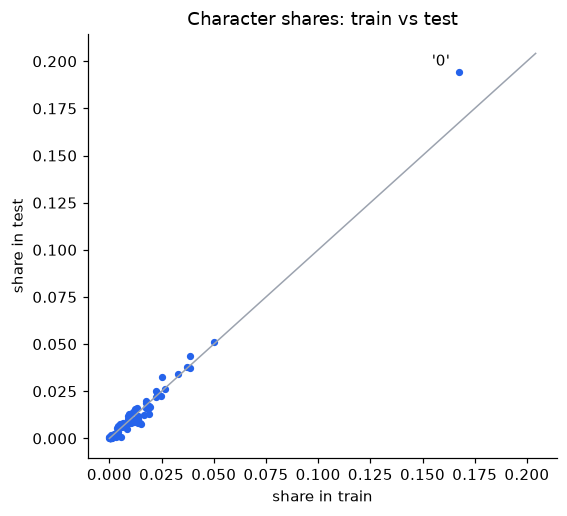

In [6]:
train_vocab = set(train_words)
unseen = [w for w in test_words if w not in train_vocab]
print(f"test words never seen in training: {len(unseen) / len(test_words):.1%}")
print("test characters never seen in training:", sorted(set("".join(test_words)) - set("".join(train_words))))

def char_share(ws):
    c = collections.Counter(ch for w in ws for ch in w); n = sum(c.values())
    return {ch: c[ch] / n for ch in c}
tr, te = char_share(train_words), char_share(test_words)
keys = sorted(set(tr) | set(te))
plt.figure(figsize=(5.5, 5))
plt.scatter([tr.get(k, 0) for k in keys], [te.get(k, 0) for k in keys], color=BLUE, s=14)
lim = max(max(tr.values()), max(te.values())) * 1.05
plt.plot([0, lim], [0, lim], color=GREY, lw=1)
plt.annotate("'0'", (tr["0"], te["0"]), textcoords="offset points", xytext=(-18, 4))
plt.xlabel("share in train"); plt.ylabel("share in test"); plt.title("Character shares: train vs test")
plt.show()

## 6. Crop shapes: stretched into a square

Training resizes every crop to 384×384 (`get_recognition_transforms`), so the aspect ratio of the word boxes
decides how much each word is distorted.

width / height: median 2.5, 95th percentile 4.4, max 11.8


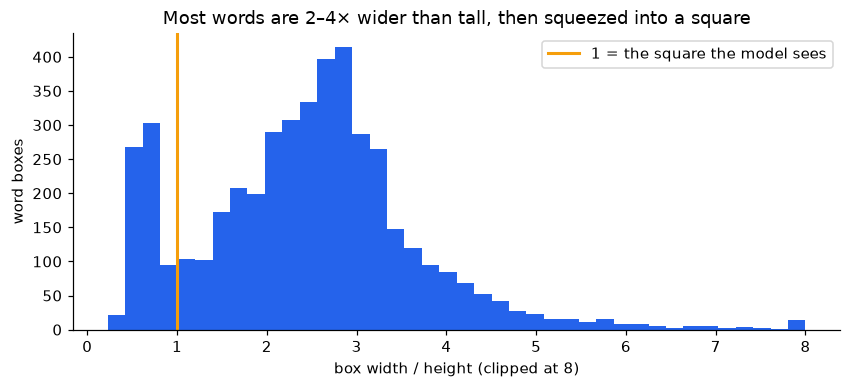

In [7]:
ratios = np.array([max(abs(b["x2"] - b["x1"]), 1) / max(abs(b["y4"] - b["y1"]), 1)
                   for boxes in md.bboxes for b in boxes])
print(f"width / height: median {np.median(ratios):.1f}, 95th percentile {np.percentile(ratios, 95):.1f}, "
      f"max {ratios.max():.1f}")
plt.figure(figsize=(9, 3.5))
plt.hist(np.clip(ratios, 0, 8), bins=40, color=BLUE)
plt.axvline(1, color=ORANGE, lw=2, label="1 = the square the model sees")
plt.xlabel("box width / height (clipped at 8)"); plt.ylabel("word boxes"); plt.legend()
plt.title("Most words are 2–4× wider than tall, then squeezed into a square")
plt.show()

## 7. Does the trained recognizer read the image?

Section 3 suggests a shortcut: predicting `1`, `0` and `Total` already lowers the loss without looking at the crop.
This section checks whether the checkpoint took it. It needs `checkpoints/trocr/best` (not in git) and downloads the
original pretrained weights (`google/vit-base-patch16-384`, `bert-base-cased`, ~780 MB) on first run.

**How fine-tuning works here.** `VisionEncoderDecoderModel`: the ViT turns the 384×384 crop into 577 vectors (576 patches
+ a summary token); the BERT decoder predicts the next character, with self-attention over the characters so far and
**cross-attention over the image patches**. Cross-attention doesn't exist in BERT, so it starts random; everything else
starts from the pretrained weights. Training uses teacher forcing (labels shifted right behind `[CLS]`), cross-entropy
over the vocabulary, and backpropagation into **all** weights (nothing frozen): AdamW, lr 5e-5, weight decay 0.01, 300
warmup steps then cosine decay, gradient clipping at 1.0.

In [8]:
import datetime, pathlib, torch
from transformers import BertLMHeadModel, VisionEncoderDecoderModel, ViTModel
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

CKPT = pathlib.Path("checkpoints/trocr/best")
HAVE_CKPT = (CKPT / "model.safetensors").exists()
if HAVE_CKPT:
    stamp = datetime.datetime.fromtimestamp((CKPT / "model.safetensors").stat().st_mtime)
    print(f"checkpoint analysed: {CKPT} (saved {stamp:%Y-%m-%d %H:%M})")
    trained = VisionEncoderDecoderModel.from_pretrained(CKPT).eval()
else:
    print(f"{CKPT} not found: skipping section 7")

checkpoint analysed: checkpoints/trocr/best (saved 2026-09-25 07:40)


### 7a. Were the pretrained weights loaded, and how far did training move them?

Cosine similarity between each trained weight matrix and its starting value: ~1 means it started from the pretrained
weights and stayed close. For the cross-attention the original random start can't be recovered, so it's compared
with a fresh random initialization: there the cosine means nothing, and only the weight scale (`weight_std`) is
informative.

In [9]:
if HAVE_CKPT:
    vit = ViTModel.from_pretrained("google/vit-base-patch16-384", add_pooling_layer=False)
    bert = BertLMHeadModel.from_pretrained("bert-base-cased", is_decoder=True, add_cross_attention=True)
    start = {**{"encoder." + k: v for k, v in vit.state_dict().items()},
             **{"decoder." + k: v for k, v in bert.state_dict().items()}}
    rows = []
    for name, w in trained.state_dict().items():
        if name not in start or w.dim() < 2:
            continue
        p, f = start[name].float().flatten(), w.float().flatten()
        part = ("encoder (ViT, pretrained)" if name.startswith("encoder.") else
                "decoder cross-attention (new, random start)" if "crossattention" in name else
                "decoder (BERT, pretrained)")
        rows.append({"part": part, "cosine to start": torch.nn.functional.cosine_similarity(p, f, dim=0).item(),
                     "relative change": ((f - p).norm() / p.norm()).item(), "std": w.float().std().item()})
    summary = pd.DataFrame(rows).groupby("part").agg(matrices=("std", "size"), cosine=("cosine to start", "mean"),
                                                     relative_change=("relative change", "mean"), weight_std=("std", "mean"))
    print(summary.round(4).to_string())
    print("\nBERT's initialization std is 0.02: a layer still at 0.02 has barely learned.")

                                             matrices  cosine  relative_change  weight_std
part                                                                                      
decoder (BERT, pretrained)                         77  1.0000           0.0095      0.0355
decoder cross-attention (new, random start)        48 -0.0001           1.4143      0.0200
encoder (ViT, pretrained)                          75  1.0000           0.0035      0.0807

BERT's initialization std is 0.02: a layer still at 0.02 has barely learned.


### 7b. Blind test: same word boxes, real image vs no image

If the model reads the crops, blank or noisy images should produce different (garbage) text. If the outputs look the
same, the decoder is generating from the text prior and ignoring the image.

In [10]:
if HAVE_CKPT:
    from ocr.dataset import crop_quad, get_recognition_transforms
    from ocr.models.BERT import CharTokenizer
    tokenizer = CharTokenizer(str(CKPT))
    _, to_tensor = get_recognition_transforms(trained.config.encoder.image_size)

    @torch.no_grad()
    def read(image, quads):
        batch = torch.stack([to_tensor(image=crop_quad(image, q))["image"] for q in quads])
        return [tokenizer.decode(ids) for ids in trained.generate(pixel_values=batch)]

    import cv2
    row = val.iloc[0]
    image = cv2.cvtColor(cv2.imread(f"dataset_receipt/images/{row.file_name}"), cv2.COLOR_BGR2RGB)
    quads = [[[b[f"x{k}"], b[f"y{k}"]] for k in range(1, 5)] for b in row.bboxes][:12]
    blind = pd.DataFrame({
        "truth": list(row.words[:12]),
        "real crops": read(image, quads),
        "white image": read(np.full_like(image, 255), quads),
        "random noise": read(np.random.default_rng(0).integers(0, 255, image.shape, dtype=np.uint8), quads),
    })
    print(blind.to_string(index=False))

   truth real crops white image random noise
       1          1         Tol            1
   SAYAP      Tolle         Tol            1
  13,636      2,000         Tol            1
       1          1         Tol            1
    PAHA       Toll         Tol            1
   BAWAH       Tole         Tol          Tol
  13,636      2,000         Tol            1
Subtotal      Tolle         Tol            1
  27,272      2,000         Tol          Tol
      P.          1         Tol            1
   Resto       Chee         Tol            1
     10%          1         Tol            1


## Findings

**1. The data is heavily imbalanced, at both levels the recognizer sees.**

| | Finding |
|---|---|
| Words | `1` alone is **8.1%** of all words; the top 10 words are **21%**. 64% of the vocabulary appears **once**. |
| Token types | **41%** of words are numbers (prices, quantities), 48% are plain words. |
| Characters | `0` alone is **17%** of all characters; digits are 36%. 12 characters appear fewer than 10 times. |
| Length | **14%** of words are a single character, mostly `1`. |
| Generalization | **34%** of test words never occur in training, so the model can't just memorize. |
| Shape | Median box is 2.5× wider than tall, but crops are stretched to a square. |

**2. The pretrained weights were loaded correctly** (7a). The ViT encoder and BERT decoder both start from their
checkpoints (cosine ≈ 1.000) and moved only slightly (~0.3% and ~0.9%). The loading log drops what should be dropped
(ViT classifier, BERT pooler and next-sentence head) and creates only the cross-attention layers.

**3. The local checkpoint (25 Sept 07:40) doesn't read the image** (7a, 7b). Its cross-attention weights are still at
their random-initialization scale (std 0.020), so the decoder barely uses the image. With a white or noise image it
produces the same outputs (`Tol`, `1`) as with real crops. On real crops it picks up only coarse cues like crop width
(short → `1`, long → `2,000`). That explains the character error rate of 0.71 on ground-truth crops: the model learned the
frequency prior from section 1, not reading.

**Why.** One learning rate (5e-5) suits nudging pretrained weights but is too small for the randomly initialized
cross-attention. Warmup covers the first ~1.5 epochs (~200 steps per epoch). And the imbalance means the language prior
alone already lowers the loss. This checkpoint may also just be early: the Colab run continued until 14:40.

**What to do, in order**
1. **Evaluate the newer Colab checkpoint** (`trocr/best`, 25 Sept 14:40) with this notebook: section 7 is the quick check.
2. **Start from `microsoft/trocr-base-printed`**, whose cross-attention is already trained: the biggest single win.
3. Otherwise, **give the cross-attention its own, higher learning rate** (~10×, via optimizer parameter groups).
4. **Rebalance the data**: down-weight `1`, `0` and `TOTAL`, up-weight rare characters, add synthetic word crops, and
   keep the aspect ratio (pad instead of stretching).
5. **Track the blind test during training**: if the error rate on real crops isn't well below the error rate on blank
   images, the model isn't reading. Also report the error rate separately for numbers and words.